# Used Car Auction Market Intelligence Pipeline
### Project: Pricing Inconsistency & Deal Scoring Analysis (2014–2015)
---
**Objective:** To analyze 524,666 auction records to identify pricing inefficiencies, quantify depreciation drivers, and flag undervalued inventory using MMR (Manheim Market Report) benchmarks.

## Six-Stage Methodology
This notebook follows a structured data science lifecycle to ensure reproducibility and accuracy:

1.  **[Define Problem]** Target: Identifying "Market Signals" (Undervalued/Overpriced).
2.  **[Data Collection]** Importing the 550k+ raw auction record dataset.
3.  **[Data Cleaning]** Robust preprocessing, text normalization, and **IQR Outlier Removal**.
4.  **[Data Analysis]** Feature engineering for Deal Scoring and PctDiff metrics.
5.  **[Data Visualization]** Quantifying the impact of Age, Condition, and Mileage.
6.  **[Interpretation]** Generating final market insights and CSV exports.
---

## 01 · Environment Setup
Initializing the analytics stack with `Pandas` for data manipulation, `Seaborn` for statistical visualization, and custom formatting for currency reporting.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

# Currency formatter for axes
price_fmt = FuncFormatter(lambda x, _: f"${int(x):,}")

## 02 · Data Collection & Initial Audit
Loading the raw dataset and performing an initial check on schema integrity and missing value distribution.

In [ ]:
df = pd.read_csv("data.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 558,837 rows × 17 columns


,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


## 03 · Data Cleaning & Normalization
Standardizing the dataset for analysis:
* **Text Cleaning:** Capitalizing 'Make' and 'Model' for categorical consistency.
* **Time Features:** Converting `SaleDate` into usable datetime objects.
* **Handling Nulls:** Removing records missing critical price or mileage data.

In [ ]:
# Shape
print("Shape:", df.shape)
print()

# Column types
print("--- Data Types ---")
df.info()
print()

# Summary statistics
print("--- Descriptive Statistics ---")
df.describe()

Shape: (558837, 17)

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              558837 non-null  int64  
 1   Year            558837 non-null  int64  
 2   Make            548536 non-null  object 
 3   Model           548438 non-null  object 
 4   Trim            548186 non-null  object 
 5   Body            545642 non-null  object 
 6   Transmission    493485 non-null  object 
 7   VIN             558833 non-null  object 
 8   State           558837 non-null  object 
 9   ConditionValue  547017 non-null  float64
 10  Odometer        558743 non-null  float64
 11  Color           558088 non-null  object 
 12  Interior        558088 non-null  object 
 13  Seller          558837 non-null  object 
 14  MMR             558799 non-null  float64
 15  SellingPrice    558825 non-null  float64
 16  SaleDate        

,Id,Year,ConditionValue,Odometer,MMR,SellingPrice
count,558837.000000,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,279420.000000,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,161322.490529,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,2.000000,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,139711.000000,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,279420.000000,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,419129.000000,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,558838.000000,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [ ]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %":     missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

print("Columns with missing values:")
print(missing_df)
print()
print(f"Duplicate VINs: {df['VIN'].duplicated().sum():,}")
print(f"Duplicate full rows: {df.duplicated().sum():,}")

Columns with missing values:
                Missing Count  Missing %
Transmission            65352      11.69
Body                    13195       2.36
ConditionValue          11820       2.12
Trim                    10651       1.91
Model                   10399       1.86
Make                    10301       1.84
Color                     749       0.13
Interior                  749       0.13
Odometer                   94       0.02
SaleDate                   38       0.01
MMR                        38       0.01
VIN                         4       0.00
SellingPrice               12       0.00

Duplicate VINs: 8,539
Duplicate full rows: 0


In [ ]:
# Define numerical columns that need type coercion
num_cols = ["SellingPrice", "Odometer", "MMR", "ConditionValue"]

# Coerce to numeric and fill missing values with column median
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# ConditionValue: try group-level median first (more accurate), fallback to global
df["ConditionValue"] = df.groupby(["Make", "Model", "Year"])["ConditionValue"] \
    .transform(lambda x: x.fillna(x.median()))
df["ConditionValue"] = df["ConditionValue"].fillna(df["ConditionValue"].median())

print("Numerical columns — missing values after cleaning:")
print(df[num_cols].isnull().sum())

Numerical columns — missing values after cleaning:
SellingPrice      0
Odometer          0
MMR               0
ConditionValue    0
dtype: int64


In [ ]:
# Standardize casing and strip whitespace
df["Make"]     = df["Make"].str.strip().str.title()
df["Model"]    = df["Model"].str.strip().str.title()
df["Body"]     = df["Body"].str.strip().str.title()
df["Color"]    = df["Color"].str.strip().str.title()
df["Interior"] = df["Interior"].str.strip().str.title()
df["State"]    = df["State"].str.strip().str.upper()

# Replace placeholder dashes with NaN, then fill with 'Unknown'
df.replace("\u2014", np.nan, inplace=True)   # em-dash (—)
df.replace("-", np.nan, inplace=True)

for col in ["Color", "Interior", "Body"]:
    df[col] = df[col].fillna("Unknown")

print("Categorical columns — sample value counts:")
print(df[["Color", "Interior", "Body"]].nunique())

Categorical columns — sample value counts:
Color       46
Interior    17
Body        47
dtype: int64


In [ ]:
# Transmission has ~12% missing/blank values.
# Fill with MODE (most frequent value) — NOT 'Unknown' — to preserve data distribution.

df["Transmission"] = df["Transmission"].str.strip().str.lower()
df["Transmission"] = df["Transmission"].replace("", np.nan)

print(f"Missing Transmission before fill: {df['Transmission'].isnull().sum():,}")

df["Transmission"] = df["Transmission"].fillna(df["Transmission"].mode()[0])

print(f"Missing Transmission after fill:  {df['Transmission'].isnull().sum():,}")
print()
print("Transmission value counts:")
print(df["Transmission"].value_counts())

Missing Transmission before fill: 65,352
Missing Transmission after fill:  0

Transmission value counts:
Transmission
automatic    541267
manual        17544
sedan            26
Name: count, dtype: int64


In [ ]:
# Parse SaleDate to datetime
df["SaleDate"] = pd.to_datetime(df["SaleDate"], errors="coerce")

print(f"SaleDate dtype: {df['SaleDate'].dtype}")
print(f"Rows with missing SaleDate: {df['SaleDate'].isnull().sum():,}")

# Drop rows where SaleDate could not be parsed — date is critical for analysis
df.dropna(subset=["SaleDate"], inplace=True)

# Deduplicate VINs — keep the most recent sale per vehicle
df = df.sort_values("SaleDate").drop_duplicates(subset="VIN", keep="last")
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after datetime cleaning: {df.shape}")

SaleDate dtype: datetime64[ns]
Rows with missing SaleDate: 38
Dataset shape after datetime cleaning: (550284, 17)


In [ ]:
def iqr_filter(data, col):
    """Remove rows where col falls outside 1.5×IQR bounds."""
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = len(data)
    data = data[(data[col] >= lower) & (data[col] <= upper)]
    print(f"{col}: removed {before - len(data):,} outliers (kept {len(data):,} rows)")
    return data

# Apply IQR filter to price and mileage
df = iqr_filter(df, "SellingPrice")
df = iqr_filter(df, "Odometer")

df.reset_index(drop=True, inplace=True)
print(f"\nFinal shape after outlier removal: {df.shape}")

SellingPrice: removed 16,109 outliers (kept 534,175 rows)
Odometer: removed 9,509 outliers (kept 524,666 rows)

Final shape after outlier removal: (524666, 17)


## 04 · Data Analysis & Feature Engineering
Transforming raw data into market intelligence by creating "Market Signals":
* **VehicleAge:** Years since manufacture.
* **PctDiff:** Percentage variance from the MMR (Manheim Market Report).
* **MarketSignal:** Classification of vehicles as **Undervalued**, **Fair**, or **Overpriced**.

In [ ]:
# --- Temporal features ---
df["SaleYear"]  = df["SaleDate"].dt.year
df["SaleMonth"] = df["SaleDate"].dt.month

# --- Vehicle age ---
df["VehicleAge"] = df["SaleYear"] - df["Year"]

# --- Price transformation (for modelling) ---
df["LogSellingPrice"] = np.log1p(df["SellingPrice"])

# --- Market gap features ---
df["PriceVsMMR"] = df["SellingPrice"] - df["MMR"]
df["PctDiff"]    = (df["PriceVsMMR"] / df["MMR"] * 100).round(2)

# --- Market signal label ---
df["MarketSignal"] = pd.cut(
    df["PctDiff"],
    bins=[-np.inf, -10, 10, np.inf],
    labels=["Undervalued", "Fair", "Overpriced"]
)

# --- Segmentation features ---
df["AgeGroup"] = pd.cut(
    df["VehicleAge"],
    bins=[0, 3, 7, 12, 50],
    labels=["New", "Mid", "Old", "Very Old"]
)

df["MileageGroup"] = pd.cut(
    df["Odometer"],
    bins=[0, 30000, 80000, 150000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

print("New features added:")
print(df[["SaleYear", "SaleMonth", "VehicleAge", "LogSellingPrice",
          "PriceVsMMR", "PctDiff", "MarketSignal", "AgeGroup", "MileageGroup"]].head())

New features added:
   SaleYear  SaleMonth  VehicleAge  LogSellingPrice  PriceVsMMR  PctDiff  \
0      2014          1           9         8.366603      -525.0   -10.88   
1      2014          1          10         8.216358        75.0     2.07   
2      2014          1           8         8.748464      -975.0   -13.40   
3      2014          1          10         8.699681      -150.0    -2.44   
4      2014          1           8         8.824825      -700.0    -9.33   

  MarketSignal AgeGroup MileageGroup  
0  Undervalued      Old         High  
1         Fair      Old         High  
2  Undervalued      Old         High  
3         Fair      Old    Very High  
4         Fair      Old         High  


## 05 · EDA: Market Drivers
Visualizing the key variables that influence auction outcomes. We focus on the correlation between **Condition Score**, **Mileage**, and **Final Selling Price**.

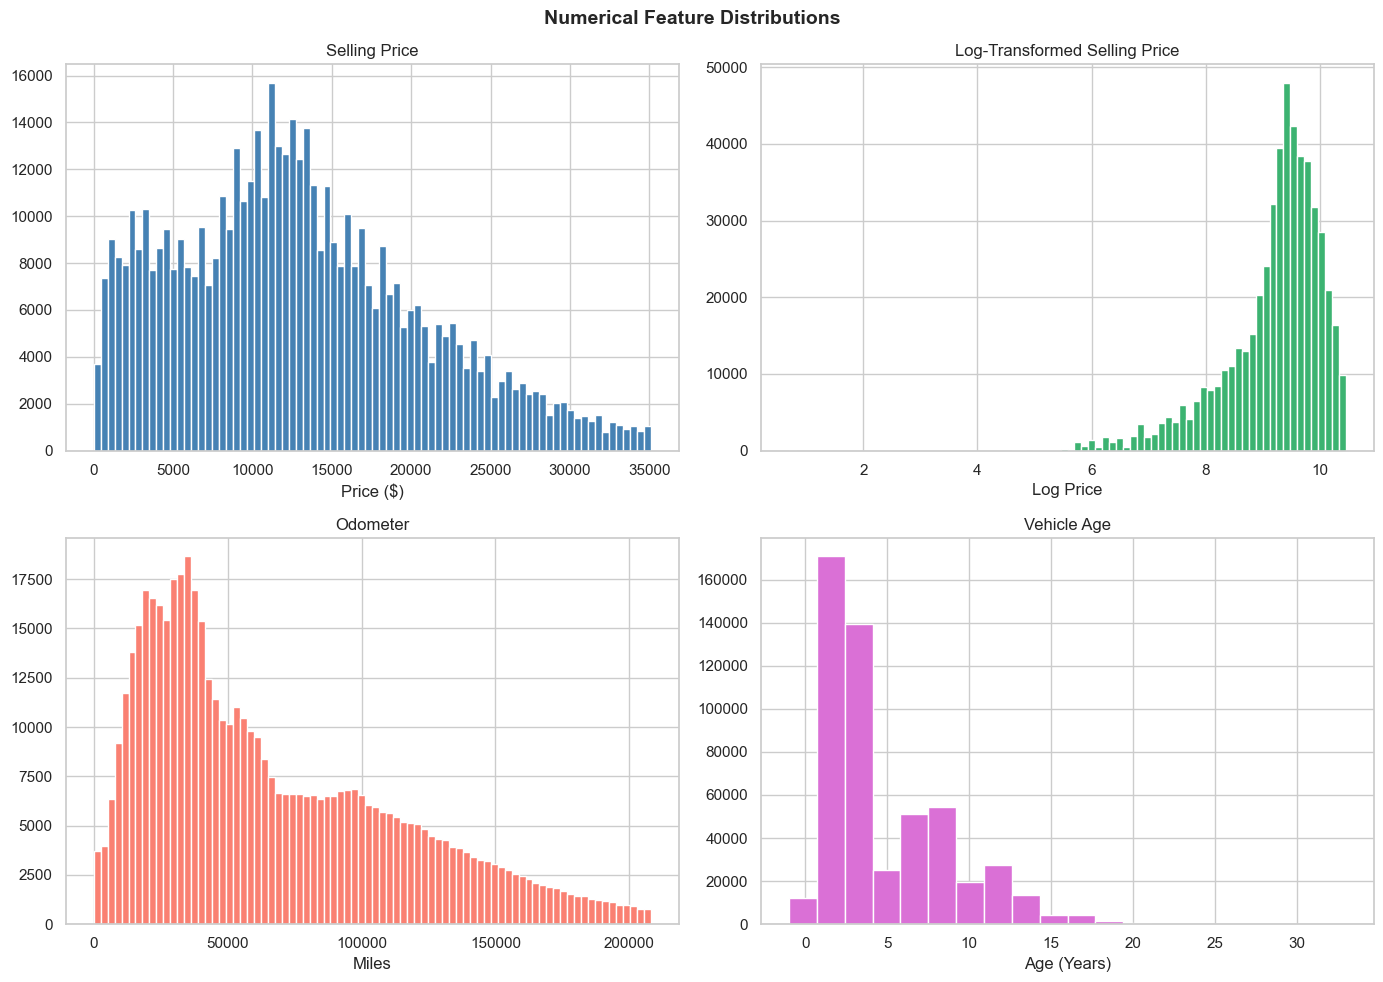

In [ ]:
# ==============================
# UNIVARIATE ANALYSIS (Numerical)
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")

# Selling Price
axes[0, 0].hist(df["SellingPrice"], bins=80, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Selling Price")
axes[0, 0].set_xlabel("Price ($)")

# Log Selling Price
axes[0, 1].hist(df["LogSellingPrice"], bins=80, color="mediumseagreen", edgecolor="white")
axes[0, 1].set_title("Log-Transformed Selling Price")
axes[0, 1].set_xlabel("Log Price")

# Odometer
axes[1, 0].hist(df["Odometer"], bins=80, color="salmon", edgecolor="white")
axes[1, 0].set_title("Odometer")
axes[1, 0].set_xlabel("Miles")

# Vehicle Age
axes[1, 1].hist(df["VehicleAge"], bins=20, color="orchid", edgecolor="white")
axes[1, 1].set_title("Vehicle Age")
axes[1, 1].set_xlabel("Age (Years)")

plt.tight_layout()
plt.show()

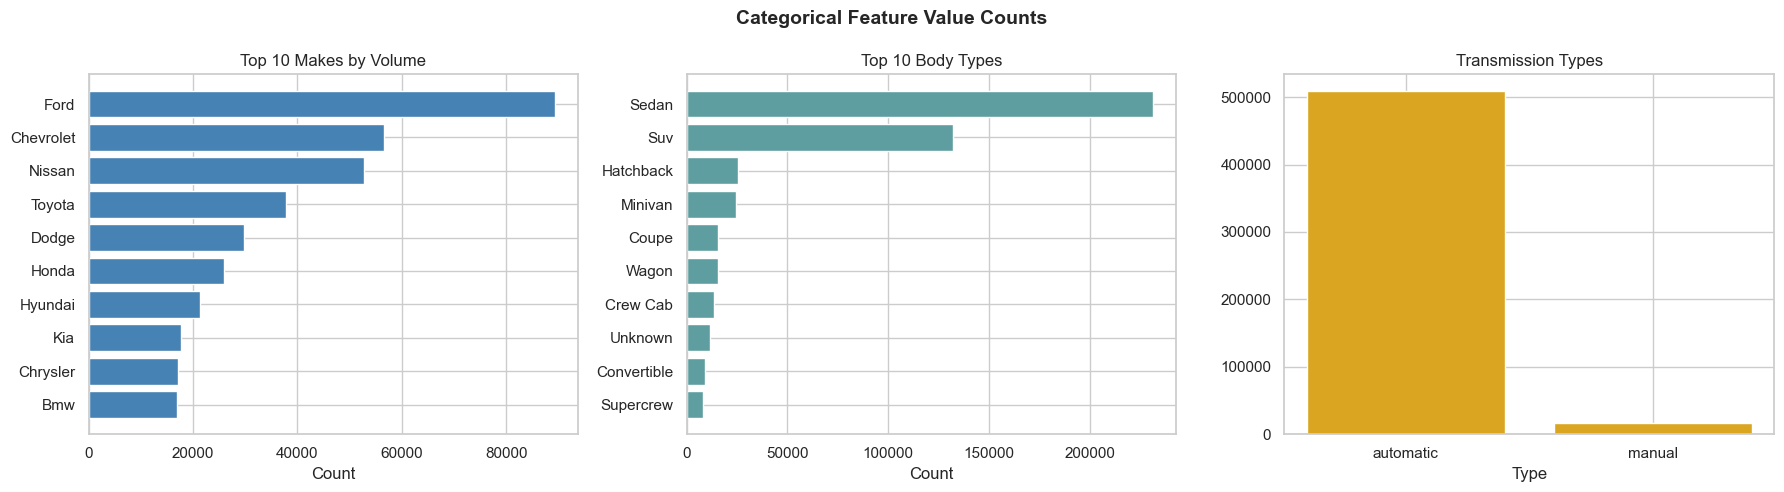

In [ ]:
# ==============================
# UNIVARIATE ANALYSIS (Categorical)
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Categorical Feature Value Counts", fontsize=14, fontweight="bold")

# Top 10 Makes
make_counts = df["Make"].value_counts().head(10)
axes[0].barh(make_counts.index[::-1], make_counts.values[::-1], color="steelblue")
axes[0].set_title("Top 10 Makes by Volume")
axes[0].set_xlabel("Count")

# Top 10 Body types
body_counts = df["Body"].value_counts().head(10)
axes[1].barh(body_counts.index[::-1], body_counts.values[::-1], color="cadetblue")
axes[1].set_title("Top 10 Body Types")
axes[1].set_xlabel("Count")

# Transmission distribution
trans_counts = df["Transmission"].value_counts()
axes[2].bar(trans_counts.index, trans_counts.values, color="goldenrod")
axes[2].set_title("Transmission Types")
axes[2].set_xlabel("Type")

plt.tight_layout()
plt.show()

C:\Users\Abd el Aziz\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


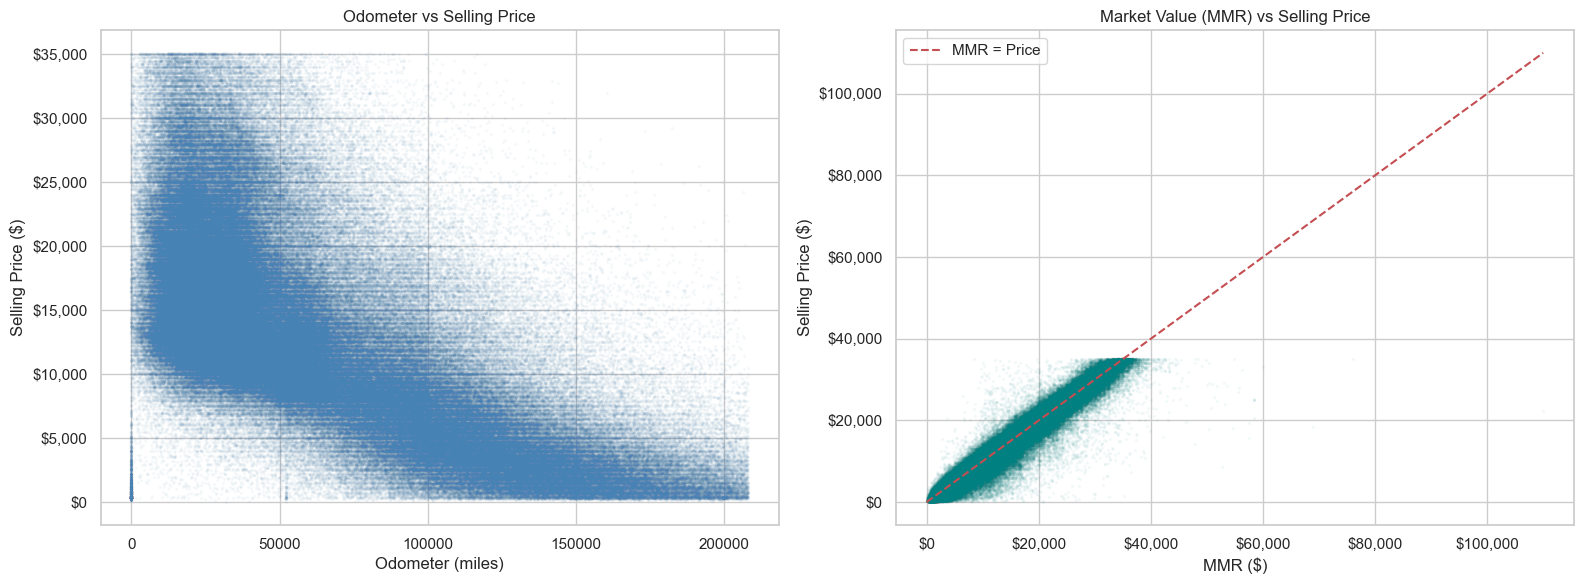

In [ ]:
# ==============================
# BIVARIATE ANALYSIS (Scatter)
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Odometer vs Selling Price
axes[0].scatter(df["Odometer"], df["SellingPrice"], alpha=0.03, s=2, color="steelblue")
axes[0].set_title("Odometer vs Selling Price")
axes[0].set_xlabel("Odometer (miles)")
axes[0].set_ylabel("Selling Price ($)")
axes[0].yaxis.set_major_formatter(price_fmt)

# MMR vs Selling Price with perfect-market reference line
axes[1].scatter(df["MMR"], df["SellingPrice"], alpha=0.03, s=2, color="teal")
max_val = max(df["MMR"].max(), df["SellingPrice"].max())
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="MMR = Price")
axes[1].set_title("Market Value (MMR) vs Selling Price")
axes[1].set_xlabel("MMR ($)")
axes[1].set_ylabel("Selling Price ($)")
axes[1].xaxis.set_major_formatter(price_fmt)
axes[1].yaxis.set_major_formatter(price_fmt)
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\Abd el Aziz\AppData\Local\Temp\ipykernel_21644\748634009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ConditionValue", y="SellingPrice", ax=axes[0], palette="coolwarm")


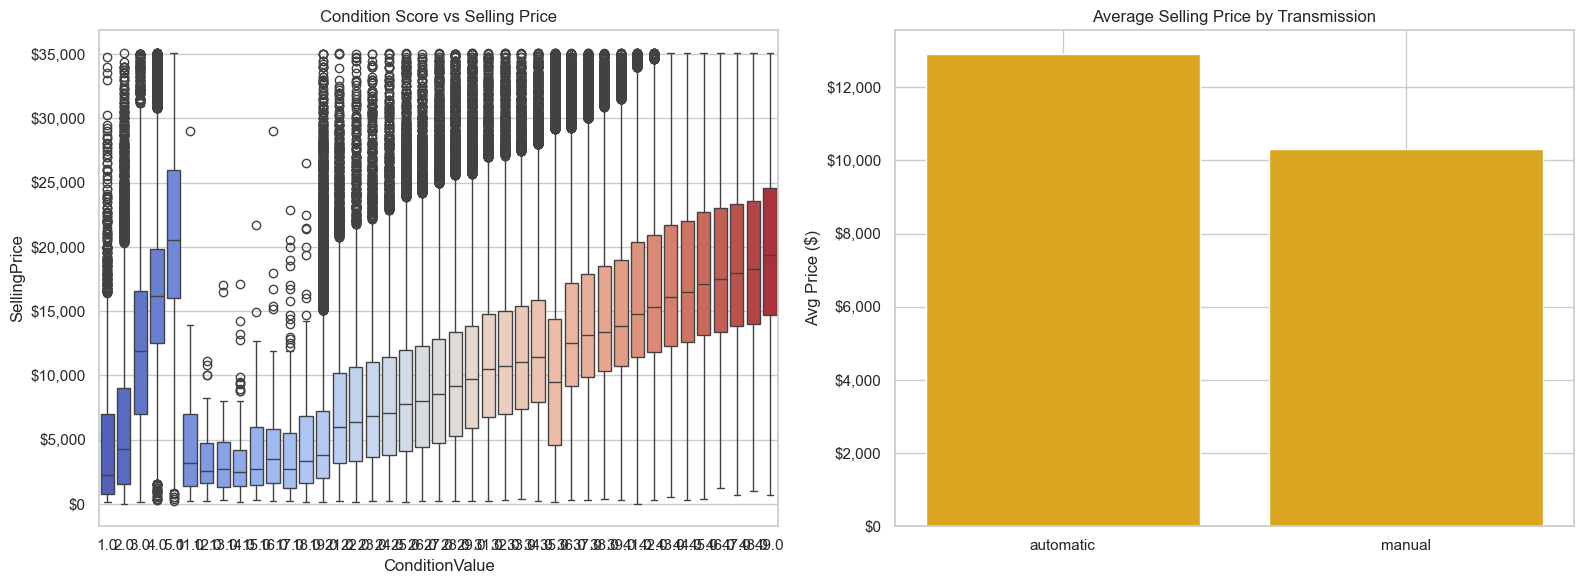

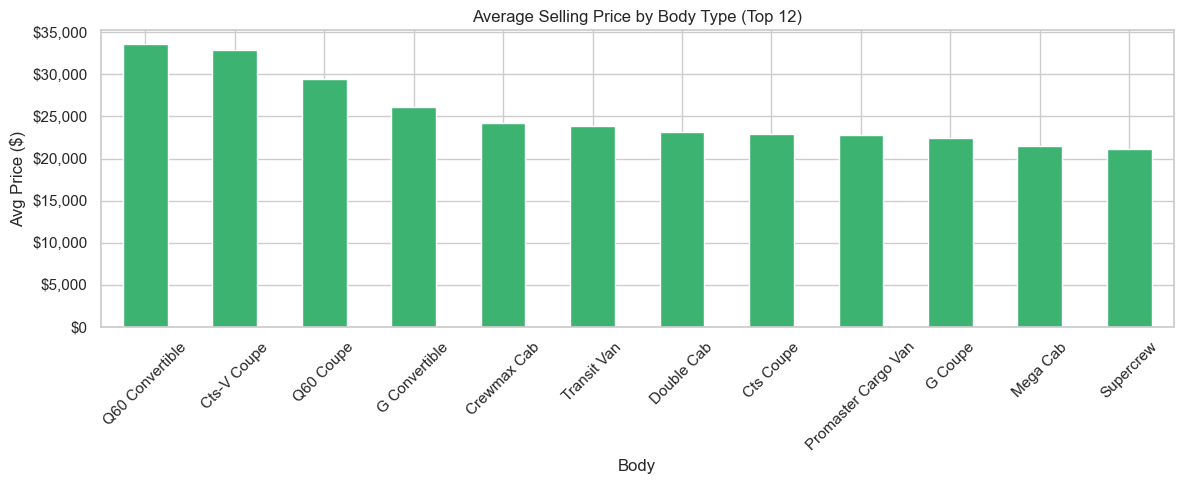

In [ ]:
# ==============================
# BIVARIATE ANALYSIS (Category vs Price)
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Condition vs Selling Price (boxplot)
sns.boxplot(data=df, x="ConditionValue", y="SellingPrice", ax=axes[0], palette="coolwarm")
axes[0].set_title("Condition Score vs Selling Price")
axes[0].yaxis.set_major_formatter(price_fmt)

# Transmission vs Average Price
trans_avg = df.groupby("Transmission")["SellingPrice"].mean().sort_values(ascending=False)
axes[1].bar(trans_avg.index, trans_avg.values, color="goldenrod")
axes[1].set_title("Average Selling Price by Transmission")
axes[1].set_ylabel("Avg Price ($)")
axes[1].yaxis.set_major_formatter(price_fmt)

plt.tight_layout()
plt.show()

# Top Body Types by Average Price
top_body_price = df.groupby("Body")["SellingPrice"].mean().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(12, 5))
top_body_price.plot(kind="bar", ax=ax, color="mediumseagreen")
ax.set_title("Average Selling Price by Body Type (Top 12)")
ax.set_ylabel("Avg Price ($)")
ax.yaxis.set_major_formatter(price_fmt)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

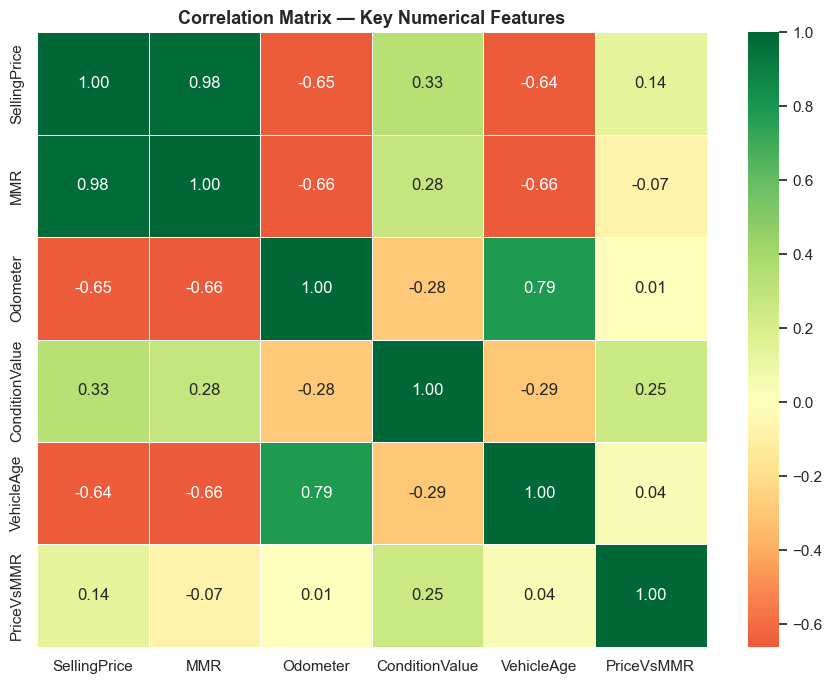


=== Price Drivers (correlation with SellingPrice) ===
SellingPrice      1.000000
MMR               0.976943
ConditionValue    0.330124
PriceVsMMR        0.142893
VehicleAge       -0.644650
Odometer         -0.654503
Name: SellingPrice, dtype: float64


In [ ]:
# ==============================
# CORRELATION HEATMAP
# ==============================

# Select key numerical features for correlation analysis
corr_cols = ["SellingPrice", "MMR", "Odometer", "ConditionValue", "VehicleAge", "PriceVsMMR"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Matrix — Key Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print ranked price drivers
print("\n=== Price Drivers (correlation with SellingPrice) ===")
print(corr_matrix["SellingPrice"].sort_values(ascending=False))

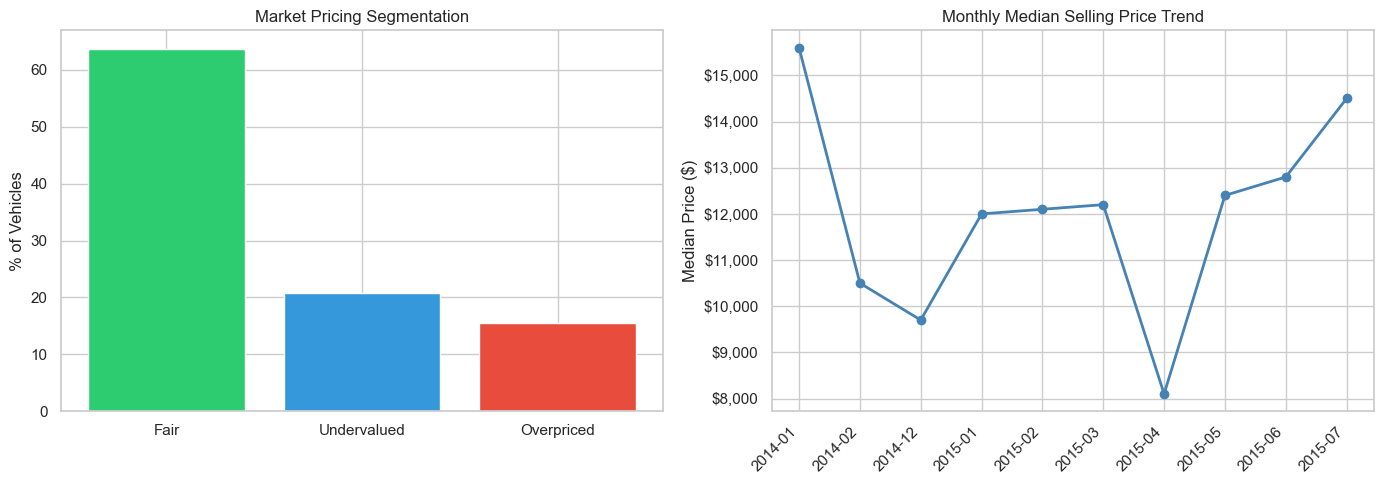

In [ ]:
# ==============================
# MARKET SIGNAL ANALYSIS
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Market signal distribution
signal_dist = df["MarketSignal"].value_counts(normalize=True) * 100
axes[0].bar(signal_dist.index, signal_dist.values,
            color=["#2ecc71", "#3498db", "#e74c3c"])
axes[0].set_title("Market Pricing Segmentation")
axes[0].set_ylabel("% of Vehicles")

# Monthly median price trend
monthly_avg = df.groupby(["SaleYear", "SaleMonth"])["SellingPrice"].median().reset_index()
monthly_avg["Period"] = monthly_avg["SaleYear"].astype(str) + "-" + monthly_avg["SaleMonth"].astype(str).str.zfill(2)
axes[1].plot(monthly_avg["Period"], monthly_avg["SellingPrice"], marker="o", linewidth=2, color="steelblue")
axes[1].set_title("Monthly Median Selling Price Trend")
axes[1].set_ylabel("Median Price ($)")
axes[1].yaxis.set_major_formatter(price_fmt)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 06 · Interpretation & Decisions
Summarizing the final dataset. The pipeline now yields a clean, engineered dataset containing **524,666** records ready for production dashboards (Power BI) or further Machine Learning modeling.

In [ ]:
# Select final columns for the cleaned, analysis-ready dataset
export_cols = [
    "Make", "Model", "Body", "Transmission", "State",
    "Year", "VehicleAge", "AgeGroup",
    "Odometer", "MileageGroup",
    "SellingPrice", "LogSellingPrice", "MMR",
    "ConditionValue",
    "SaleDate", "SaleYear", "SaleMonth",
    "PriceVsMMR", "PctDiff", "MarketSignal"
]

# Keep only columns that exist in the dataframe
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv("cleaned_auction_data.csv", index=False)

print(f"Cleaned dataset saved → cleaned_auction_data.csv")
print(f"Rows: {len(df):,}  |  Columns: {len(export_cols)}")
print()
print("=== FINAL SUMMARY ===")
print(f"  Total vehicles:        {len(df):,}")
print(f"  Avg Selling Price:     ${df['SellingPrice'].mean():,.0f}")
print(f"  Median Selling Price:  ${df['SellingPrice'].median():,.0f}")
print(f"  Avg Vehicle Age:       {df['VehicleAge'].mean():.1f} years")
print(f"  Avg Odometer:          {df['Odometer'].mean():,.0f} miles")
print(f"  % Sold Above MMR:      {(df['PriceVsMMR'] > 0).mean() * 100:.1f}%")

Cleaned dataset saved → cleaned_auction_data.csv
Rows: 524,666  |  Columns: 20

=== FINAL SUMMARY ===
  Total vehicles:        524,666
  Avg Selling Price:     $12,826
  Median Selling Price:  $12,000
  Avg Vehicle Age:       4.8 years
  Avg Odometer:          66,397 miles
  % Sold Above MMR:      46.5%
